In [ ]:
## import all necessary libaraies
import os
import time

import numpy as np
import pandas as pd
import scipy.sparse as sp
import argparse
import sklearn.metrics
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score

import torch
torch.manual_seed(2022)
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, TensorDataset

# from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
# from torch_geometric.nn import GATConv, global_mean_pool
# from torch_geometric.datasets import Planetoid
# from torch_geometric.datasets import MNISTSuperpixels

# import torch_geometric.transforms as T

# import matplotlib.pyplot as plt
from utils import *
from layer_model import *

import gc

gc.collect()

torch.cuda.empty_cache()


# ## set all the parameters
# parser = argparse.ArgumentParser()
# parser.add_argument('--lr', type=float, default = 0.01, help='learning rate.')
# parser.add_argument('--big_lr', type=str2bool, nargs='?', default = True, help='use the larger learning rate.')
# parser.add_argument('--num_gene', type=int, default = 1000, help='# of genes')
# parser.add_argument('--omic_mode', type=int, default = 0, help='which modes of omic to use')
# parser.add_argument('--num_omic', type=int, default = 1, help='# of the omic(s) used')
# parser.add_argument('--cancer_subtype', type=str2bool, nargs='?', default = False, help='if use the cancer subtype for classification')
# parser.add_argument('--specific_type',type=str, default='brca', choices=['brca','luad'], help='which cancer type to use for subtype classification')
# parser.add_argument('--shuffle_index',type=int, default=0, help='which shuffle index to use')
# parser.add_argument('--batch_size', type=int, default = 16, help='# of genes')
# parser.add_argument('--epochs', type=int, default = 100, help='# of epoch')
# parser.add_argument('--dropout', type=float, default = 0.6, help='dropout rate')
# parser.add_argument('--model', type=str, default = 'gat', choices=['gat','gatv2','gcn','multi-gcn','baseline'], help='which model to use')
# parser.add_argument('--decay', type=float, default = 0.9, help='decay rate of the learing rate')
# parser.add_argument('--poolsize', type=int, default = 8, help='the max pooling size')
# parser.add_argument('--poolrate', type=float, default = 0.8, help='the pooling rate used in the self-attention pooling layer')
# parser.add_argument('--gene_gene', type=str2bool, nargs='?', default = True, help='if use the Gene-gene inner connections')
# parser.add_argument('--mirna_gene', type=str2bool, nargs='?', default = True, help='if use mirna-mrna connections')
# parser.add_argument('--mirna_mirna', type=str2bool, nargs='?', default = True, help='include the meta-path within the mirna')
# parser.add_argument('--parallel', type=str2bool, nargs='?', default = True, help='if use the parallel structure')
# parser.add_argument('--l2', type=str2bool, nargs='?', default = True, help='if use the l2 regularization')
# parser.add_argument('--decoder', type=str2bool, nargs='?', default = True, help='if use the decoder for the graph')
# parser.add_argument('--edge_attribute', type=str2bool, nargs='?', default = False, help='if use multi-demension attributes for edges')
# parser.add_argument('--edge_weight', type=str2bool, nargs='?', default = False, help='if use score as the edge weight instead of binary edges')
# parser.add_argument('--train_ratio', type=float, default = 0.8, help='the ratio of the training data')
# parser.add_argument('--test_ratio', type=float, default = 0.1, help='the ratio of the test data')
# args = parser.parse_args()

## double check corresponding num_omic and network options according to the selcted omic_mode
## mode 0: mRNA
## mode 1: miRNA
## mode 2: mRNA + miRNA
## mode 3: mRNA + CNV
## mode 4: mRNA + CNV + miRNA
# args.num_omic = omic_mode_translation(args.omic_mode)
# args.gene_gene, args.mirna_gene, args.mirna_mirna, num_mirna = validate_network_choice(args.omic_mode, args.gene_gene, args.mirna_gene, args.mirna_mirna)

# if args.omic_mode == 1:
#     args.num_gene = 0

# if args.model == 'baseline':
#     args.decoder = False
#     args.parallel = False
# ## print the validated input arguments
# print('Current arguments:')
# print(args)

path = 'data/cancer/'

# python cancer_test.py --model gat --num_gene 100 --cancer_subtype True --omic_mode 4 --shuffle_index 0 --gene_gene True --mirna_gene True --mirna_mirna True --parallel True --l2 True --decoder False --poolsize 8 --edge_weight True --epochs 200 --train_ratio 0.7 --test_ratio 0.1


expression_variance_path = path + 'expression_variance.tsv' # present
non_null_index_path = path + 'biogrid_non_null.csv' # present
shuffle_index_path = path + 'brca_shuffle_index.tsv' # present
cancer_subtype_label_path = path + 'brca_subtype.csv' # present
expression_data_path = path + 'expression_data_brca.tsv' # present
cnv_data_path = path + 'cnv_data_brca.tsv' # present
mirna_data_path = path +'mirna_data_brca.tsv' # present
adjacency_matrix_path = path + 'adj_matrix_biogrid.npz' # present
mirna_to_gene_matrix_path = path + 'standardized_mirna_mrna_edge_filtered_at_eight_with_top_100_mirna.npz' # present

# python cancer_test.py --model gat --num_gene 100 --cancer_subtype True --omic_mode 4 --shuffle_index 0 --gene_gene True --mirna_gene True --mirna_mirna True --parallel True --l2 True --decoder False --poolsize 8 --edge_weight True --epochs 200 --train_ratio 0.7 --test_ratio 0.1

lr = 0.01
big_lr = True
specific_type = 'brca'
shuffle_index = 0
batch_size = 16
epochs = 100
dropout = 0.6
model = 'gat'
decay = 0.9
poolsize = 8
poolrate = 0.8
parallel = True
l2 = True
decoder = True
edge_weight = False
train_ratio = 0.8
test_ratio = 0.1

omic_mode = 4
gene_gene = True
mirna_gene = True
mirna_mirna = True
num_gene = 100
cancer_subtype = True
edge_attribute = False
num_omic = 1

## use the loading function to load the data
if omic_mode < 3:
    expr_all_data, mirna_all_data = load_exp_and_real_mirna_data(expression_data_path, mirna_data_path)

    adj, train_data_all, labels, shuffle_index = down_sampling_exp_and_real_mirna_data(expression_variance_path=expression_variance_path,
                                                                        expression_data=expr_all_data,
                                                                        mirna_data=mirna_all_data,
                                                                        omic_mode=omic_mode,
                                                                        non_null_index_path=non_null_index_path,
                                                                        shuffle_index_path=shuffle_index_path,
                                                                        adjacency_matrix_path=adjacency_matrix_path,
                                                                        mirna_to_gene_matrix_path=mirna_to_gene_matrix_path,
                                                                        gene_gene=gene_gene,
                                                                        mirna_gene=mirna_gene,
                                                                        mirna_mirna=mirna_mirna,
                                                                        number_gene=num_gene,
                                                                        singleton=False)
else:
    expr_all_data, cnv_all_data, mirna_all_data = load_exp_cnv_and_real_mirna_data(expression_data_path, cnv_data_path, mirna_data_path)

    adj, train_data_all, labels, shuffle_index = down_sampling_exp_cnv_and_real_mirna_data(expression_variance_path=expression_variance_path,
                                                                        expression_data=expr_all_data,
                                                                        cnv_data=cnv_all_data,
                                                                        mirna_data=mirna_all_data,
                                                                        omic_mode=omic_mode,
                                                                        non_null_index_path=non_null_index_path,
                                                                        shuffle_index_path=shuffle_index_path,
                                                                        adjacency_matrix_path=adjacency_matrix_path,
                                                                        mirna_to_gene_matrix_path=mirna_to_gene_matrix_path,
                                                                        gene_gene=gene_gene,
                                                                        mirna_gene=mirna_gene,
                                                                        mirna_mirna=mirna_mirna,
                                                                        number_gene=num_gene,
                                                                        singleton=False)


## filter data if a specific cancer type is selected
if cancer_subtype:
    train_data_all, labels = filter_data_by_cancer_type(cancer_subtype_label_path,
                                                        train_data_all,
                                                        expr_all_data)

## process the labels to make sure it starts from 0
from sklearn import preprocessing
from torch_sparse import SparseTensor

le = preprocessing.LabelEncoder()
labels = le.fit_transform(labels)  
# if not args.singleton:      
#     adj, train_data_all = removeZeroAdj(adj, train_data_all)

## adds the self connecting edges and convert the adj to edge_index format
adj_for_loss = adj.todense()
adj = adj/np.max(adj)
adj = adj.astype('float32')
adj.setdiag(0)
adj = adj + sp.eye(adj.shape[0])

adj = sp.coo_matrix(adj)
edge_index = torch.stack([torch.tensor(adj.row), torch.tensor(adj.col)], dim=0)
edge_weight = torch.Tensor(adj.data)

## convert uniformly edge weight into multi-dimension edge attributes if needed.
if edge_attribute:
    edge_attribute = disassemble_edge_weights(edge_weight, edge_index, num_gene, num_omic)

# print(edge_weight.shape)

## split the training and test data
shuffle_index = shuffle_index.astype(np.int32).reshape(-1)

train_size, val_size = int(len(shuffle_index)* train_ratio), int(len(shuffle_index)* (1- test_ratio))
train_data = np.asarray(train_data_all).astype(np.float32)[shuffle_index[0:train_size]]
val_data = np.asarray(train_data_all).astype(np.float32)[shuffle_index[train_size:val_size]]
test_data = np.asarray(train_data_all).astype(np.float32)[shuffle_index[val_size:]]
train_labels = labels[np.array(shuffle_index[0:train_size])]
val_labels = labels[shuffle_index[train_size:val_size]]
test_labels = labels[shuffle_index[val_size:]]

##########################################################################
# compute inverse-frequency class weights from training labels only (so we have no leakage)
# so if there are 500 samples of class 1, and 50 samples of class 2, then class 1 gets weight 0.1 and class 2 gets weight 1.0
# so the model will be penalized 10 times more for misclassifying class 2 samples than class 1 samples, this should help with our imbalanced dataset
# https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html
unique_classes = np.unique(train_labels)
class_weights_b = compute_class_weight('balanced', classes=unique_classes, y=train_labels)
# class_weights_b = compute_class_weight(None, classes=unique_classes, y=train_labels)

# fill zeros for any classes absent in train (shouldn't happen but be safe)
class_weights_np = np.zeros(len(np.unique(labels)))
class_weights_np[unique_classes] = class_weights_b

USE_CLASS_WEIGHTS = False # False = default behvaiour, True = added to see if weight helps or not
##########################################################################

# ## dropout some training samples
# train_data, train_labels = dropout_data(train_data, train_labels, 0.75)

# ll, cnt = np.unique(train_labels,return_counts=True)

nclass = len(np.unique(labels))
# print(nclass)

train_labels = train_labels.astype(np.int64)
test_labels = test_labels.astype(np.int64)
val_labels = val_labels.astype(np.int64)
train_data = torch.FloatTensor(train_data)
test_data = torch.FloatTensor(test_data)
val_data = torch.FloatTensor(val_data)
train_labels = torch.LongTensor(train_labels)
test_labels = torch.LongTensor(test_labels)
val_labels = torch.LongTensor(val_labels)
class_weights = torch.FloatTensor(class_weights_np)

dset_train = TensorDataset(train_data, train_labels)
train_loader = DataLoader(dset_train, batch_size = batch_size, shuffle = True)
dset_test = TensorDataset(test_data, test_labels)
test_loader = DataLoader(dset_test, shuffle = False)
dset_val = TensorDataset(val_data, val_labels)
val_loader = DataLoader(dset_val, batch_size = batch_size, shuffle = True)


# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')

print('Device', device)


In [ ]:
# class imbalance check
unique, counts = np.unique(labels, return_counts=True)
print("class distribution:")
for cls, cnt in zip(unique, counts):
    print(f"\tclass {cls}: {cnt}")

print(f"total samples: {len(labels)}")

# data shapes
print(f"\ntrain_data_all shape: {np.asarray(train_data_all).shape}")

display(train_data_all[:5])

class distribution:
	class 0: 175
	class 1: 80
	class 2: 529
	class 3: 197
total samples: 981

train_data_all shape: (981, 200, 2)


array([[[0.07318501, 0.15959596],
        [0.75409836, 0.26121212],
        [0.02517564, 0.15959596],
        ...,
        [0.1121972 , 0.        ],
        [0.11644709, 0.        ],
        [0.10242244, 0.        ]],

       [[0.49117814, 0.26121212],
        [0.9408082 , 0.28060606],
        [0.06033011, 0.25656566],
        ...,
        [0.12069698, 0.        ],
        [0.09689758, 0.        ],
        [0.10582235, 0.        ]],

       [[0.10882016, 0.19676768],
        [0.30068729, 0.26222222],
        [0.        , 0.19676768],
        ...,
        [0.11432214, 0.        ],
        [0.12367191, 0.        ],
        [0.13897153, 0.        ]],

       [[0.62680192, 0.26121212],
        [0.3011212 , 0.25878788],
        [0.29204485, 0.26121212],
        ...,
        [0.09689758, 0.        ],
        [0.10582235, 0.        ],
        [0.10582235, 0.        ]],

       [[0.61200429, 0.25818182],
        [0.38478028, 0.32080808],
        [0.2738478 , 0.25818182],
        ...,
        [

In [ ]:
display(expr_all_data[:5])

,A1BG,A1CF,A2M,A2ML1,A4GALT,A4GNT,AAAS,AACS,AADAC,AADACL2,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,sample,icluster_cluster_assignment
610,0.446721,0.000000,0.731850,0.073185,0.357728,0.191452,0.547424,0.590749,0.000000,0.0,...,0.411593,0.584309,0.626464,0.469555,0.599532,0.689696,0.637588,0.597775,TCGA-3C-AAAU,19
611,0.449630,0.000000,0.733637,0.137735,0.416050,0.035857,0.557769,0.552647,0.060330,0.0,...,0.337507,0.501423,0.591349,0.434832,0.525896,0.707456,0.590211,0.493455,TCGA-3C-AALI,2
612,0.500000,0.053265,0.750859,0.000000,0.525200,0.000000,0.544101,0.605956,0.053265,0.0,...,0.296678,0.518900,0.549255,0.479954,0.518900,0.710767,0.565865,0.515464,TCGA-3C-AALJ,17
613,0.405232,0.000000,0.716498,0.075280,0.479979,0.000000,0.512547,0.520555,0.104645,0.0,...,0.310198,0.468767,0.521089,0.398292,0.493860,0.665777,0.513081,0.505072,TCGA-3C-AALK,2
749,0.433012,0.027331,0.709003,0.114684,0.451233,0.027331,0.518757,0.520900,0.027331,0.0,...,0.302251,0.467846,0.538049,0.209539,0.514469,0.642015,0.519829,0.524652,TCGA-4H-AAAK,19


In [ ]:
display(cnv_all_data[:5])

,A1BG,A1CF,A2M,A2ML1,A4GALT,A4GNT,AAAS,AACS,AADAC,AADACL2,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
610,0.261212,0.166667,0.298788,0.298788,0.140808,0.313535,0.159596,0.166263,0.313535,0.313535,...,0.278384,0.166667,0.316566,0.316566,0.313535,0.275152,0.275152,0.303434,0.146667,0.311515
611,0.280606,0.168081,0.259798,0.259798,0.153535,0.357374,0.261212,0.261212,0.357374,0.357374,...,0.499596,0.168081,0.427273,0.427273,0.357374,0.172323,0.172323,0.352929,0.155152,0.172323
612,0.262222,0.268081,0.266263,0.266263,0.121414,0.233737,0.196768,0.336162,0.233737,0.233737,...,0.195152,0.541616,0.248485,0.248485,0.233535,0.195758,0.195758,0.260606,0.121010,0.195758
613,0.258384,0.264040,0.260808,0.260808,0.265253,0.249495,0.261212,0.261212,0.249495,0.249495,...,0.266263,0.264040,0.263434,0.263434,0.249495,0.256566,0.256566,0.264040,0.131111,0.256566
749,0.320808,0.263030,0.191717,0.191717,0.255556,0.260606,0.258182,0.258182,0.260606,0.260606,...,0.256566,0.263030,0.257172,0.257172,0.261010,0.261212,0.261212,0.260404,0.126061,0.261212


In [ ]:
display(mirna_all_data[:5])

,17,24,30,32,38,42,43,44,48,60,...,636,640,644,647,651,653,659,677,705,732
0,0.209945,0.292393,0.811730,0.762856,0.102422,0.339142,0.211220,0.170846,0.112197,0.150871,...,0.124097,0.428389,0.220994,0.278368,0.161496,0.675733,0.395665,0.112197,0.116447,0.102422
1,0.150871,0.348916,0.798555,0.728007,0.096898,0.096898,0.158521,0.154696,0.096898,0.096898,...,0.132597,0.369316,0.126647,0.190820,0.126647,0.607310,0.431789,0.120697,0.096898,0.105822
2,0.163621,0.096898,0.661283,0.689758,0.103272,0.096898,0.148321,0.165746,0.311942,0.400340,...,0.187845,0.371441,0.175946,0.240544,0.131747,0.630259,0.419040,0.114322,0.123672,0.138972
3,0.179346,0.096898,0.720782,0.760306,0.096898,0.096898,0.271993,0.240969,0.120697,0.105822,...,0.096898,0.416065,0.113897,0.120697,0.186570,0.480663,0.523162,0.096898,0.105822,0.105822
4,0.163196,0.114322,0.718232,0.778581,0.096898,0.096898,0.232469,0.180620,0.096898,0.096898,...,0.133447,0.329367,0.175521,0.114322,0.138547,0.403740,0.524862,0.133447,0.143221,0.163196


In [ ]:
print(f"adj shape: {adj.shape}")
print(f"adj nnz (non-zero entries): {adj.nnz}")
print(f"adj density: {adj.nnz / (adj.shape[0] * adj.shape[1]) * 100}%")

# check how many nodes out of the total are isolated
num_isolated = adj_for_loss.shape[0] - np.count_nonzero(adj_for_loss.sum(axis=0))
print(f"number of isolated nodes: {num_isolated}")
print(f"percentage of isolated nodes: {num_isolated / adj_for_loss.shape[0] * 100:.2f}%")

adj shape: (200, 200)
adj nnz (non-zero entries): 262
adj density: 0.655%
number of isolated nodes: 163
percentage of isolated nodes: 81.50%


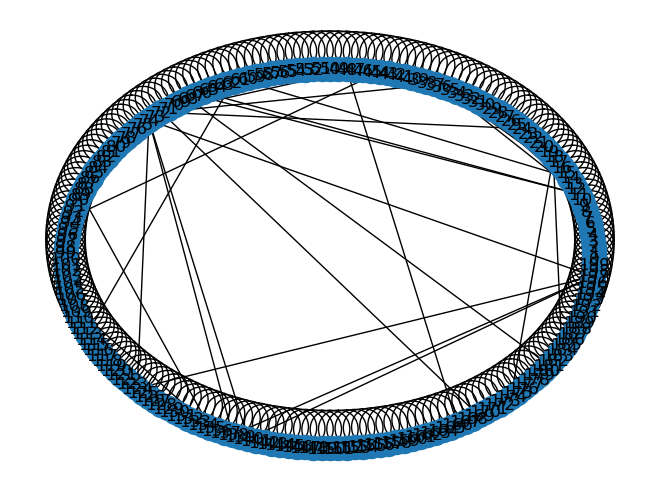

In [ ]:
import networkx as nx
import numpy as np

# matrix = np.array([[0, 1, 0], [1, 0, 1], [0, 1, 0]])

from scipy.sparse import coo_matrix

# m = coo_matrix(adj)
G = nx.from_numpy_array(adj.todense())
import matplotlib.pyplot as plt

# pos = nx.spring_layout(G)
pos = nx.circular_layout(G)
nx.draw(G, pos, with_labels=True)#, node_size=5, font_size=8)
plt.show()

In [ ]:
# for data in [expr_all_data, cnv_all_data, mirna_all_data]:
for name, data in [("expression", expr_all_data), ("cnv", cnv_all_data), ("miRNA", mirna_all_data)]:
    print(f"======= {name} ========")
    print(f"shape: {data.shape}")
    print(f"first few datapoints:\n{data.iloc[:5, :5]}")

    # print(f"last two columns:\n{data.iloc[:5, -2:]}")

======= expression ========
shape: (981, 17946)
first few datapoints:
         A1BG      A1CF       A2M     A2ML1    A4GALT
610  0.446721  0.000000  0.731850  0.073185  0.357728
611  0.449630  0.000000  0.733637  0.137735  0.416050
612  0.500000  0.053265  0.750859  0.000000  0.525200
613  0.405232  0.000000  0.716498  0.075280  0.479979
749  0.433012  0.027331  0.709003  0.114684  0.451233
======= cnv ========
shape: (981, 17944)
first few datapoints:
         A1BG      A1CF       A2M     A2ML1    A4GALT
610  0.261212  0.166667  0.298788  0.298788  0.140808
611  0.280606  0.168081  0.259798  0.259798  0.153535
612  0.262222  0.268081  0.266263  0.266263  0.121414
613  0.258384  0.264040  0.260808  0.260808  0.265253
749  0.320808  0.263030  0.191717  0.191717  0.255556
======= miRNA ========
shape: (981, 100)
first few datapoints:
         17        24        30        32        38
0  0.209945  0.292393  0.811730  0.762856  0.102422
1  0.150871  0.348916  0.798555  0.728007  0.096898


In [ ]:
icluster_cluster_assignment = expr_all_data["icluster_cluster_assignment"]
print(f"icluster_cluster_assignment.value_counts():\n{icluster_cluster_assignment.value_counts()}")

icluster_cluster_assignment.value_counts():
19    531
17    122
2      94
13     68
20     61
25     39
10     16
14     15
27     10
8      10
7       9
3       3
1       1
23      1
22      1
Name: icluster_cluster_assignment, dtype: int64


In [ ]:
# train/val/test split check
print(f"\n=== split sizes ===")
print(f"train: {len(train_labels)} ({len(train_labels)/len(labels)*100:.1f}%)")
print(f"val: {len(val_labels)} ({len(val_labels)/len(labels)*100:.1f}%)")
print(f"test: {len(test_labels)} ({len(test_labels)/len(labels)*100:.1f}%)")


=== split sizes ===
train: 784 (79.9%)
val: 98 (10.0%)
test: 99 (10.1%)


In [ ]:
print(f"\n==== class weights ===")
for i, w in enumerate(class_weights_np):
    print(f"class {i}: {w:.4f}")


==== class weights ===
class 0: 1.4101
class 1: 3.2131
class 2: 0.4506
class 3: 1.3154
